# regrid / landsea 典型场景演示

本 Notebook 面向**用法示例**（算法输入直接读预处理后的 `cli_input/`）：

1. **环境准备**：导入迁移版 / 原版插件，以及对比绘图辅助函数
2. **场景一** `bilinear`：本场景读取输入并绘图 → 调用与对照
3. **场景二** `nearest-with-mask`：本场景读取输入并绘图 → 调用与对照
4. **场景三** `bilinear-2`（多 member）：本场景读取输入并绘图 → 调用与对照
5. **方法对照**：同一输入上比较 `bilinear` 与 `bilinear-2`
6. **CLI 应用示例**：`tran_regrid.process` 与原版 Improver CLI 对照 KGO

官方样例 → meb 的预处理已抽离为脚本，请先在仓库根目录执行：

```bash
python regrid/cli/preprocess_test_data.py
```

各场景自包含：只依赖第 1 节环境，可按需单独运行某一场景。
全量模式验收见 `regrid/test/`（算法输入同样读 `cli_input/`）。


## 1. 环境准备


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import iris
import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
for path in (PROJECT_ROOT, PROJECT_ROOT / "improver-1.18.7"):
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from improver.regrid.landsea import RegridLandSea as OriginalRegridLandSea  # pyright: ignore[reportMissingImports]
from regrid import RegridLandSea
from regrid.cli.tran_regrid import process as cli_process

DATA_DIR = (PACKAGE_ROOT / "test_data").resolve()
CLI_INPUT_DIR = DATA_DIR / "cli_input"
CLI_OUTPUT_DIR = DATA_DIR / "cli_output"
CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required = [
    "global_cutout.nc",
    "ukvx_grid.nc",
    "glm_landmask.nc",
    "ukvx_landmask.nc",
    "engl_landmask.nc",
    "global_cutout_multi_realization.nc",
]
missing = [n for n in required if not (CLI_INPUT_DIR / n).exists()]
if missing:
    raise FileNotFoundError(
        "缺少预处理后的测试数据: "
        + ", ".join(missing)
        + "。请先在仓库根目录运行: python regrid/cli/preprocess_test_data.py"
    )

print("DATA_DIR =", DATA_DIR)
print("CLI_INPUT_DIR =", CLI_INPUT_DIR)


def to_compare_array(data) -> np.ndarray:
    if isinstance(data, xr.DataArray):
        arr = np.asarray(data.values, dtype=np.float64)
    elif hasattr(data, "data"):
        arr = np.asarray(data.data, dtype=np.float64)
    else:
        arr = np.asarray(data, dtype=np.float64)
    return np.squeeze(arr)


def summarize_triple(tag: str, migrated, original, kgo, atol: float = 1e-4, rtol: float = 1e-4):
    a = to_compare_array(migrated)
    b = to_compare_array(original)
    c = to_compare_array(kgo)
    if len({a.shape, b.shape, c.shape}) != 1:
        raise ValueError(
            f"{tag}: shape mismatch migrated={a.shape} original={b.shape} kgo={c.shape}"
        )

    print(f"[{tag}] shape={a.shape} atol={atol}")
    all_ok = True
    for x, y, label in (
        (a, c, "migrated vs KGO"),
        (b, c, "original  vs KGO"),
        (a, b, "migrated vs original"),
    ):
        diff = x - y
        finite = np.isfinite(diff)
        abs_max = float(np.nanmax(np.abs(diff))) if finite.any() else np.nan
        close = np.allclose(x, y, atol=atol, rtol=rtol, equal_nan=True)
        print(f"  {label}: max|diff|={abs_max:.6g} allclose={close}")
        all_ok = all_ok and close
    print(f"  => {'PASS' if all_ok else 'DIFF'}\n")
    return all_ok


def plot_triple(
    migrated,
    original,
    kgo,
    title: str,
    member_index: int = 0,
    panel_titles=("修改后方法", "原方法", "KGO"),
    cmap: str = "coolwarm",
):
    panels = []
    for data in (migrated, original, kgo):
        arr = to_compare_array(data)
        if arr.ndim == 3:
            arr = arr[member_index]
        panels.append(arr)

    # 三面板共享色标，便于目视对比
    vmin = min(float(np.nanmin(p)) for p in panels)
    vmax = max(float(np.nanmax(p)) for p in panels)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, data, ttl in zip(axes, panels, panel_titles):
        im = ax.imshow(data, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(ttl)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_input_panels(
    items,
    *,
    ncols: int = 3,
    member_index: int = 0,
    figsize_per=(4.2, 3.6),
    share_scale_by_cmap: bool = True,
):
    """绘制若干输入场（二维 squeeze；三维取 member_index）。

    items: (data, title, cmap)；气温场请用 "coolwarm"。
    默认按 cmap 分组共享 vmin/vmax（与结果图 plot_triple 一致）；
    掩码等使用 gray 时单独成组，不与气温混色标。
    """
    n = len(items)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        squeeze=False,
    )

    prepared = []
    for data, title, cmap in items:
        arr = to_compare_array(data)
        if arr.ndim == 3:
            arr = arr[member_index]
        prepared.append((arr, title, cmap))

    # 同一 cmap 的面板共享色标
    scale_by_cmap = {}
    if share_scale_by_cmap:
        for arr, _, cmap in prepared:
            lo, hi = float(np.nanmin(arr)), float(np.nanmax(arr))
            if cmap in scale_by_cmap:
                old_lo, old_hi = scale_by_cmap[cmap]
                scale_by_cmap[cmap] = (min(old_lo, lo), max(old_hi, hi))
            else:
                scale_by_cmap[cmap] = (lo, hi)

    for i, (arr, title, cmap) in enumerate(prepared):
        ax = axes[i // ncols][i % ncols]
        kw = {"cmap": cmap}
        if share_scale_by_cmap and cmap in scale_by_cmap:
            kw["vmin"], kw["vmax"] = scale_by_cmap[cmap]
        im = ax.imshow(arr, origin="lower", **kw)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    plt.tight_layout()
    plt.show()


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_DIR = D:\workspace\improver\regrid\test_data
CLI_INPUT_DIR = D:\workspace\improver\regrid\test_data\cli_input


## 2. 场景一：标准双线性重网格（`bilinear`）

本场景读取 `global_cutout` → `ukvx_grid`，绘制输入后调用迁移版 / 原版，并与 KGO 对照。


源场: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 75, 71) lat.units= degrees_north
目标: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 49, 53) lat.units= m
目标是否投影: True


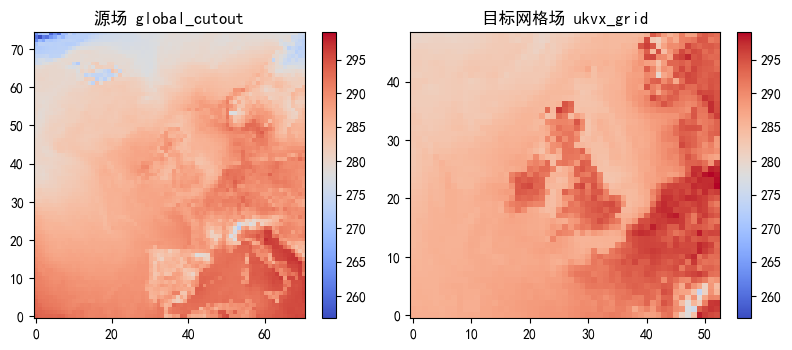

In [2]:
# 本场景输入：修改后读 cli_input；原版 / KGO 读官方 nc
src = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "global_cutout.nc"))
tgt = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "ukvx_grid.nc"))
orig_src = iris.load_cube(str(DATA_DIR / "global_cutout.nc"))
orig_tgt = iris.load_cube(str(DATA_DIR / "ukvx_grid.nc"))
kgo_bilinear = iris.load_cube(str(DATA_DIR / "basic/kgo.nc"), "air_temperature")

print("源场:", src.dims, src.shape, "lat.units=", src.coords["lat"].attrs.get("units"))
print("目标:", tgt.dims, tgt.shape, "lat.units=", tgt.coords["lat"].attrs.get("units"))
print("目标是否投影:", "grid_mapping_attrs" in tgt.attrs)

plot_input_panels(
    [
        (src, "源场 global_cutout", "coolwarm"),
        (tgt, "目标网格场 ukvx_grid", "coolwarm"),
    ],
    ncols=2,
)


[bilinear] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=6.10352e-05 allclose=True
  original  vs KGO: max|diff|=6.10352e-05 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



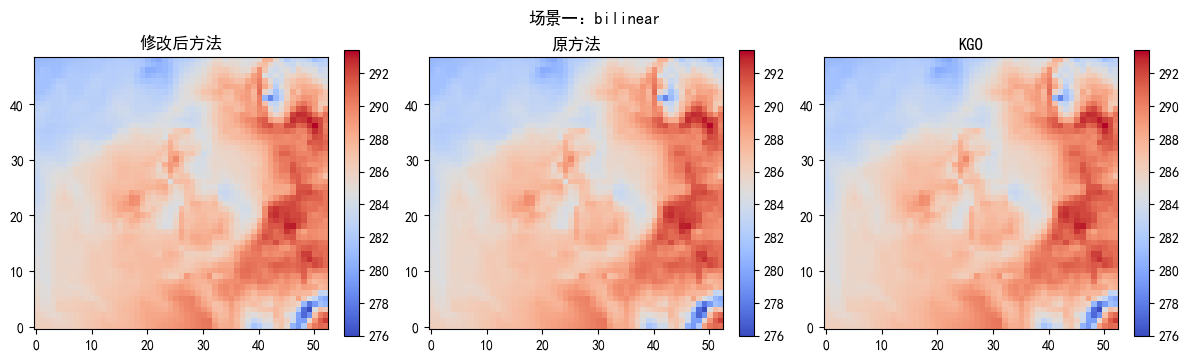

In [3]:
# 修改后方法调用
migrated_bilinear = RegridLandSea(regrid_mode="bilinear")(
    src, tgt, regridded_title="test"
)
# 原方法调用
original_bilinear = OriginalRegridLandSea(regrid_mode="bilinear")(
    orig_src,
    orig_tgt,
    regridded_title="test",
)

summarize_triple("bilinear", migrated_bilinear, original_bilinear, kgo_bilinear)
plot_triple(
    migrated_bilinear,
    original_bilinear,
    kgo_bilinear,
    title="场景一：bilinear",
)


## 3. 场景二：海陆感知最近邻（`nearest-with-mask`）

本场景读取源场、源/目标海陆掩码，绘制输入后调用迁移版 / 原版，并与 KGO 对照。


源场: (1, 1, 1, 1, 75, 71) air_temperature
源掩码: (1, 1, 1, 1, 384, 512) land_binary_mask
目标掩码: (1, 1, 1, 1, 49, 53) land_binary_mask


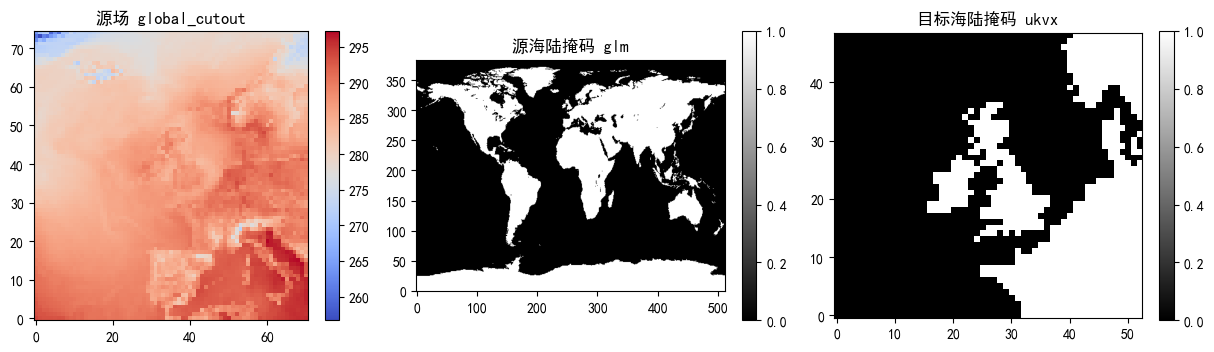

In [4]:
# 本场景输入：掩码重网格（源场 + 源掩码 → 目标掩码网格）
src = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "global_cutout.nc"))
src_mask = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "glm_landmask.nc"))
tgt_mask = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "ukvx_landmask.nc"))
orig_src = iris.load_cube(str(DATA_DIR / "global_cutout.nc"))
orig_src_mask = iris.load_cube(str(DATA_DIR / "landmask/glm_landmask.nc"))
orig_tgt_mask = iris.load_cube(str(DATA_DIR / "landmask/ukvx_landmask.nc"))
kgo_nwm = iris.load_cube(str(DATA_DIR / "landmask/kgo.nc"), "air_temperature")

print("源场:", src.shape, src.name)
print("源掩码:", src_mask.shape, src_mask.name)
print("目标掩码:", tgt_mask.shape, tgt_mask.name)

plot_input_panels(
    [
        (src, "源场 global_cutout", "coolwarm"),
        (src_mask, "源海陆掩码 glm", "gray"),
        (tgt_mask, "目标海陆掩码 ukvx", "gray"),
    ],
    ncols=3,
)


[nearest-with-mask] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



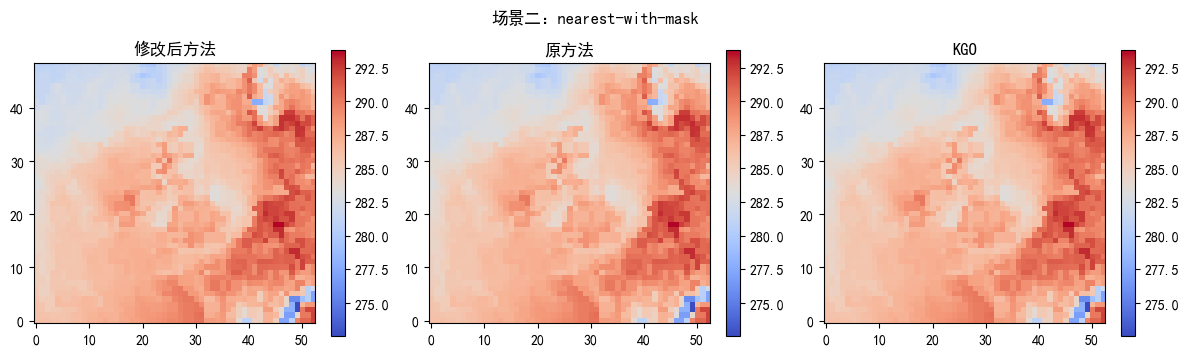

In [5]:
# 修改后方法调用
migrated_nwm = RegridLandSea(
    regrid_mode="nearest-with-mask",
    landmask=src_mask,
    landmask_vicinity=100000,
)(src, tgt_mask, regridded_title="test")
# 原方法调用
original_nwm = OriginalRegridLandSea(
    regrid_mode="nearest-with-mask",
    landmask=orig_src_mask,
    landmask_vicinity=100000,
)(
    orig_src,
    orig_tgt_mask,
    regridded_title="test",
)

summarize_triple("nearest-with-mask", migrated_nwm, original_nwm, kgo_nwm)
plot_triple(
    migrated_nwm,
    original_nwm,
    kgo_nwm,
    title="场景二：nearest-with-mask",
)


## 4. 场景三：新版双线性 + 多 member（`bilinear-2`）

本场景读取多 member 源场与目标掩码网格，绘制输入后调用迁移版 / 原版，并与 KGO 对照。


多 realization 源场: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (3, 1, 1, 1, 37, 36)
member 坐标: ['0' '1' '2']
目标掩码网格: (1, 1, 1, 1, 49, 53) land_binary_mask


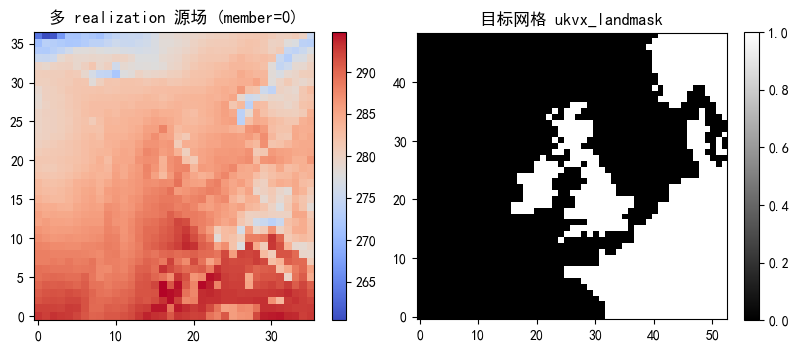

In [ ]:
# 本场景输入：多 member 源场 → 目标 ukvx 掩码网格
src_multi = meb.read_griddata_from_nc(
    str(CLI_INPUT_DIR / "global_cutout_multi_realization.nc")
)
tgt_mask = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "ukvx_landmask.nc"))
orig_src_multi = iris.load_cube(
    str(DATA_DIR / "landmask/global_cutout_multi_realization.nc")
)
orig_tgt_mask = iris.load_cube(str(DATA_DIR / "landmask/ukvx_landmask.nc"))
kgo_multi = iris.load_cube(str(DATA_DIR / "bilinear_2/kgo_multi_realization.nc"))

print("多 member 源场:", src_multi.dims, src_multi.shape)
print("member 坐标:", src_multi.coords["member"].values)
print("目标掩码网格:", tgt_mask.shape, tgt_mask.name)

plot_input_panels(
    [
        (src_multi, "多 member 源场 (member=0)", "coolwarm"),
        (tgt_mask, "目标网格 ukvx_landmask", "gray"),
    ],
    ncols=2,
)


[bilinear-2 (multi)] shape=(3, 49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



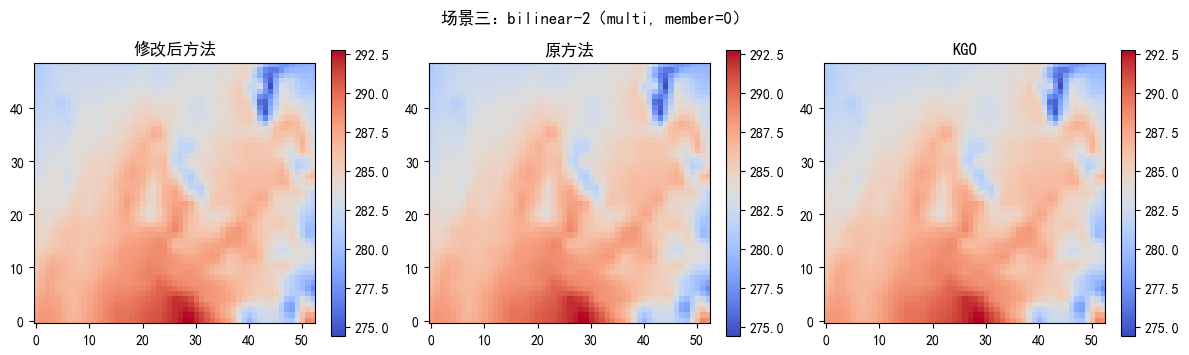

In [7]:
# 修改后方法调用
migrated_multi = RegridLandSea(regrid_mode="bilinear-2")(
    src_multi, tgt_mask, regridded_title="test"
)
# 原方法调用
original_multi = OriginalRegridLandSea(regrid_mode="bilinear-2")(
    orig_src_multi,
    orig_tgt_mask,
    regridded_title="test",
)

summarize_triple("bilinear-2 (multi)", migrated_multi, original_multi, kgo_multi)
plot_triple(
    migrated_multi,
    original_multi,
    kgo_multi,
    title="场景三：bilinear-2（multi, member=0）",
    member_index=0,
)


## 5. 对照：`bilinear` vs `bilinear-2`

两套都是双线性，但实现路径不同（详见 `docs/regrid_landsea.md`）：

| | `bilinear` | `bilinear-2` |
|--|--|--|
| 引擎 | `regrid_rectilinear`（scipy `RegularGridInterpolator`） | `RegridWithLandSeaMask`（自写经纬邻点权重） |
| 坐标 | 在**源场 CRS** 的规则网上采样 | 目标点先转**经纬**，再在经纬规则源网上加权 |
| 域外 | 由 `extrapolation_mode` 控制 | 统一填 NaN |

本节自行读取与场景一相同的输入（`global_cutout` → `ukvx_grid`），只比较**修改后**两种模式的数值差；不引入 KGO。


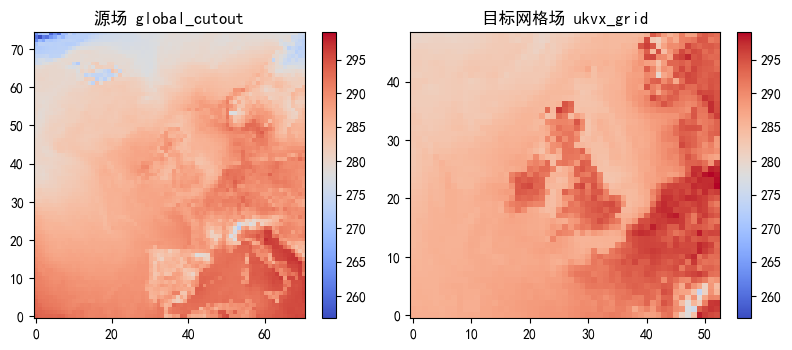

[bilinear vs bilinear-2] shape=(49, 53)
  max|diff|=6.10352e-05
  有限值格点数=2597, |diff|>1e-6 的点数=758, |diff|>1e-4 的点数=0
  缺测位置不一致点数=0
  allclose(atol=1e-4)=True


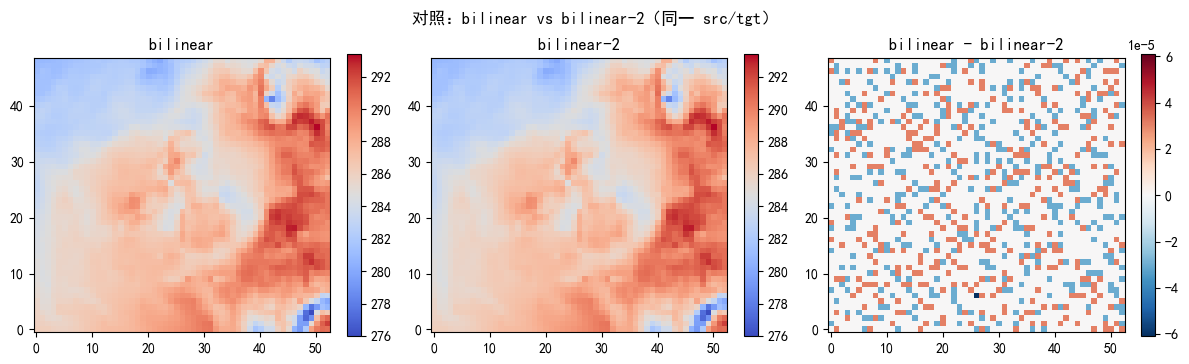

In [8]:
# 本场景输入（与场景一相同路径，自包含）
src = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "global_cutout.nc"))
tgt = meb.read_griddata_from_nc(str(CLI_INPUT_DIR / "ukvx_grid.nc"))

plot_input_panels(
    [
        (src, "源场 global_cutout", "coolwarm"),
        (tgt, "目标网格场 ukvx_grid", "coolwarm"),
    ],
    ncols=2,
)

cmp_bilinear = RegridLandSea(regrid_mode="bilinear")(
    src, tgt, regridded_title="test"
)
cmp_bilinear2 = RegridLandSea(regrid_mode="bilinear-2")(
    src, tgt, regridded_title="test"
)

a = to_compare_array(cmp_bilinear)
b = to_compare_array(cmp_bilinear2)
if a.shape != b.shape:
    raise ValueError(f"shape mismatch: bilinear={a.shape} bilinear-2={b.shape}")

diff = a - b
finite = np.isfinite(diff)
abs_diff = np.abs(diff)
abs_max = float(np.nanmax(abs_diff)) if finite.any() else np.nan
both_ok = np.isfinite(a) & np.isfinite(b)
n_both = int(both_ok.sum())
n_gt_1e4 = int(np.sum(abs_diff[both_ok] > 1e-4)) if n_both else 0
n_gt_1e6 = int(np.sum(abs_diff[both_ok] > 1e-6)) if n_both else 0
n_nan_xor = int(np.sum(np.isfinite(a) != np.isfinite(b)))

print(f"[bilinear vs bilinear-2] shape={a.shape}")
print(f"  max|diff|={abs_max:.6g}")
print(f"  有限值格点数={n_both}, |diff|>1e-6 的点数={n_gt_1e6}, |diff|>1e-4 的点数={n_gt_1e4}")
print(f"  缺测位置不一致点数={n_nan_xor}")
print(
    f"  allclose(atol=1e-4)={np.allclose(a, b, atol=1e-4, rtol=1e-4, equal_nan=True)}"
)

panels = [a, b, diff]
panel_titles = ("bilinear", "bilinear-2", "bilinear - bilinear-2")
vmin = min(float(np.nanmin(p)) for p in panels[:2])
vmax = max(float(np.nanmax(p)) for p in panels[:2])
dmax = float(np.nanmax(np.abs(diff))) if finite.any() else 1.0
if dmax == 0:
    dmax = 1e-12

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
im0 = axes[0].imshow(panels[0], origin="lower", cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0].set_title(panel_titles[0])
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(panels[1], origin="lower", cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1].set_title(panel_titles[1])
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(panels[2], origin="lower", cmap="RdBu_r", vmin=-dmax, vmax=dmax)
axes[2].set_title(panel_titles[2])
fig.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle("对照：bilinear vs bilinear-2（同一 src/tgt）")
plt.tight_layout()
plt.show()


## 6. CLI 应用示例与对比

与第 2–4 节三种模式对应：`6.1 bilinear`、`6.2 nearest-with-mask`、`6.3 bilinear-2`。
第 5 节为两种双线性引擎的数值对照（无 CLI）。
对比用的 KGO 变量复用第 2–4 节已读取的 `kgo_*`；若单独跑 CLI 小节，请先运行对应场景的读数单元。

- **修改后 CLI**：调用 `regrid.cli.tran_regrid.process`，输入为预处理脚本写出的 `cli_input/`，结果写入 `cli_output/`。
- **原方法 CLI**：通过 `python -m improver.cli regrid` 处理**原官方样例**，写出 `cli_output/original_cli_*.nc`。
- **对比**：三方面图为 **修改后CLI | 原方法CLI | KGO**。

终端脚本示例：`python regrid/cli/tran_regrid.py`


In [9]:
def run_original_improver_regrid(
    cube_path: Path,
    target_grid_path: Path,
    output_path: Path,
    *,
    land_sea_mask_path: Path | None = None,
    regrid_mode: str = "bilinear",
    extrapolation_mode: str = "nanmask",
    land_sea_mask_vicinity: float = 25000.0,
    regridded_title: str | None = None,
) -> Path:
    """调用 Improver 库 CLI：`python -m improver.cli regrid ...`，处理原测试数据。"""
    env = os.environ.copy()
    improver_root = str(PROJECT_ROOT / "improver-1.18.7")
    env["PYTHONPATH"] = improver_root + os.pathsep + env.get("PYTHONPATH", "")

    cmd = [
        sys.executable,
        "-m",
        "improver.cli",
        "regrid",
        str(cube_path),
        str(target_grid_path),
    ]
    if land_sea_mask_path is not None:
        cmd.append(str(land_sea_mask_path))
    cmd.extend(
        [
            "--regrid-mode",
            regrid_mode,
            "--extrapolation-mode",
            extrapolation_mode,
            "--land-sea-mask-vicinity",
            str(land_sea_mask_vicinity),
            "--output",
            str(output_path),
        ]
    )
    if regridded_title is not None:
        cmd.extend(["--regridded-title", regridded_title])

    # Improver save_netcdf 在 Windows 上无法用 rename 覆盖已存在文件
    if output_path.exists():
        output_path.unlink()

    print("运行原方法 CLI:")
    print(" ", " ".join(cmd))
    completed = subprocess.run(cmd, env=env, check=True, capture_output=True, text=True)
    if completed.stdout.strip():
        print(completed.stdout)
    if completed.stderr.strip():
        # iris / pkg_resources 等常见告警打到 stderr，仅提示尾部
        print(completed.stderr[-500:])
    print("写出:", output_path, "size=", output_path.stat().st_size)
    return output_path


### 6.1 bilinear


修改后 CLI bilinear 写出: D:\workspace\improver\regrid\test_data\cli_output\cli_bilinear_result.nc
运行原方法 CLI:
  d:\workspace\improver\venv\Scripts\python.exe -m improver.cli regrid D:\workspace\improver\regrid\test_data\global_cutout.nc D:\workspace\improver\regrid\test_data\ukvx_grid.nc --regrid-mode bilinear --extrapolation-mode nanmask --land-sea-mask-vicinity 25000.0 --output D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear.nc --regridded-title Global Model Forecast on UK 2 km Standard Grid
写出: D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear.nc size= 27333
[CLI bilinear] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=6.10352e-05 allclose=True
  original  vs KGO: max|diff|=6.10352e-05 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



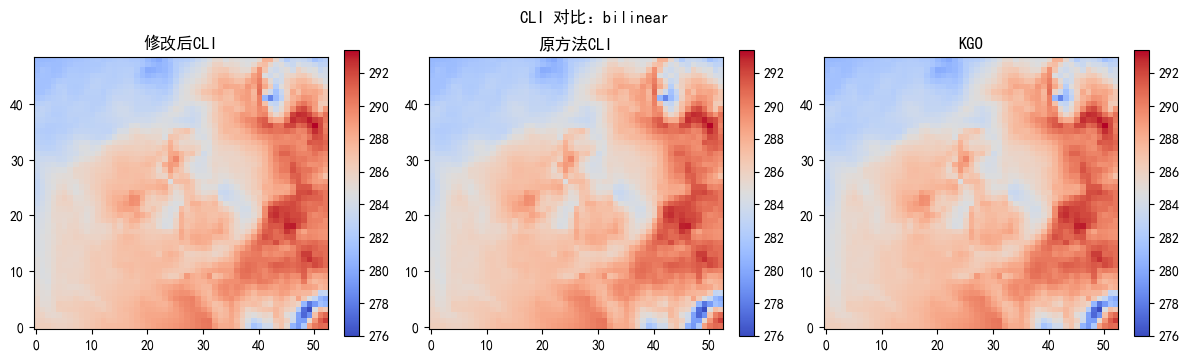

In [10]:
cli_bilinear_out = CLI_OUTPUT_DIR / "cli_bilinear_result.nc"
orig_cli_bilinear_out = CLI_OUTPUT_DIR / "original_cli_bilinear.nc"

# 修改后 CLI
cli_bilinear = cli_process(
    str(CLI_INPUT_DIR / "global_cutout.nc"),
    str(CLI_INPUT_DIR / "ukvx_grid.nc"),
    land_sea_mask_path=None,
    output_path=str(cli_bilinear_out),
    regrid_mode="bilinear",
    regridded_title="Global Model Forecast on UK 2 km Standard Grid",
)
print("修改后 CLI bilinear 写出:", cli_bilinear_out)

# 原方法 CLI
run_original_improver_regrid(
    DATA_DIR / "global_cutout.nc",
    DATA_DIR / "ukvx_grid.nc",
    orig_cli_bilinear_out,
    regrid_mode="bilinear",
    regridded_title="Global Model Forecast on UK 2 km Standard Grid",
)
orig_cli_bilinear = iris.load_cube(str(orig_cli_bilinear_out), "air_temperature")

summarize_triple("CLI bilinear", cli_bilinear, orig_cli_bilinear, kgo_bilinear)
plot_triple(
    cli_bilinear,
    orig_cli_bilinear,
    kgo_bilinear,
    title="CLI 对比：bilinear",
    panel_titles=("修改后CLI", "原方法CLI", "KGO"),
)


### 6.2 nearest-with-mask


修改后 CLI nearest-with-mask 写出: D:\workspace\improver\regrid\test_data\cli_output\cli_nearest_with_mask_result.nc
运行原方法 CLI:
  d:\workspace\improver\venv\Scripts\python.exe -m improver.cli regrid D:\workspace\improver\regrid\test_data\global_cutout.nc D:\workspace\improver\regrid\test_data\landmask\ukvx_landmask.nc D:\workspace\improver\regrid\test_data\landmask\glm_landmask.nc --regrid-mode nearest-with-mask --extrapolation-mode nanmask --land-sea-mask-vicinity 100000.0 --output D:\workspace\improver\regrid\test_data\cli_output\original_cli_nearest_with_mask.nc --regridded-title test
写出: D:\workspace\improver\regrid\test_data\cli_output\original_cli_nearest_with_mask.nc size= 24667
[CLI nearest-with-mask] shape=(49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



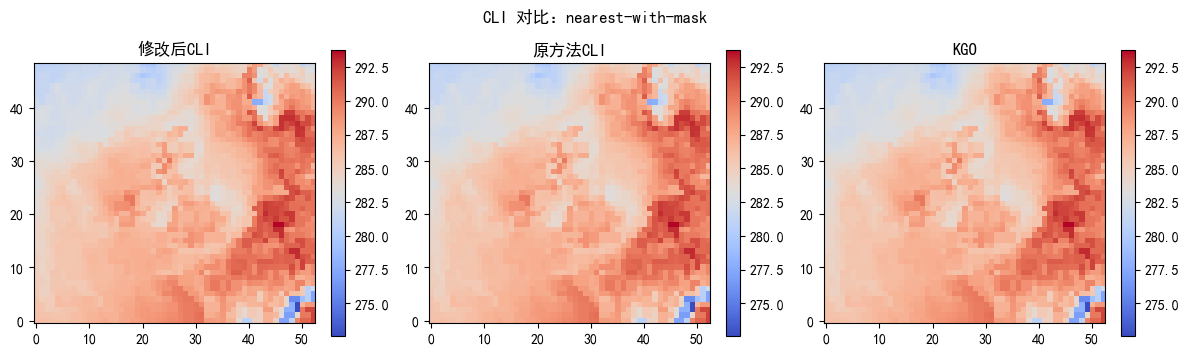

In [11]:
cli_nwm_out = CLI_OUTPUT_DIR / "cli_nearest_with_mask_result.nc"
orig_cli_nwm_out = CLI_OUTPUT_DIR / "original_cli_nearest_with_mask.nc"

# 修改后 CLI
cli_nwm = cli_process(
    str(CLI_INPUT_DIR / "global_cutout.nc"),
    str(CLI_INPUT_DIR / "ukvx_landmask.nc"),
    land_sea_mask_path=str(CLI_INPUT_DIR / "glm_landmask.nc"),
    output_path=str(cli_nwm_out),
    regrid_mode="nearest-with-mask",
    land_sea_mask_vicinity=100000.0,
    regridded_title="test",
)
print("修改后 CLI nearest-with-mask 写出:", cli_nwm_out)

# 原方法 CLI
run_original_improver_regrid(
    DATA_DIR / "global_cutout.nc",
    DATA_DIR / "landmask/ukvx_landmask.nc",
    orig_cli_nwm_out,
    land_sea_mask_path=DATA_DIR / "landmask/glm_landmask.nc",
    regrid_mode="nearest-with-mask",
    land_sea_mask_vicinity=100000.0,
    regridded_title="test",
)
orig_cli_nwm = iris.load_cube(str(orig_cli_nwm_out), "air_temperature")

summarize_triple("CLI nearest-with-mask", cli_nwm, orig_cli_nwm, kgo_nwm)
plot_triple(
    cli_nwm,
    orig_cli_nwm,
    kgo_nwm,
    title="CLI 对比：nearest-with-mask",
    panel_titles=("修改后CLI", "原方法CLI", "KGO"),
)


### 6.3 bilinear-2（多 realization）


修改后 CLI bilinear-2 multi 写出: D:\workspace\improver\regrid\test_data\cli_output\cli_bilinear2_multi_result.nc
运行原方法 CLI:
  d:\workspace\improver\venv\Scripts\python.exe -m improver.cli regrid D:\workspace\improver\regrid\test_data\landmask\global_cutout_multi_realization.nc D:\workspace\improver\regrid\test_data\landmask\ukvx_landmask.nc --regrid-mode bilinear-2 --extrapolation-mode nanmask --land-sea-mask-vicinity 25000.0 --output D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear2_multi.nc --regridded-title test
写出: D:\workspace\improver\regrid\test_data\cli_output\original_cli_bilinear2_multi.nc size= 40482
[CLI bilinear-2 multi] shape=(3, 49, 53) atol=0.0001
  migrated vs KGO: max|diff|=0 allclose=True
  original  vs KGO: max|diff|=0 allclose=True
  migrated vs original: max|diff|=0 allclose=True
  => PASS



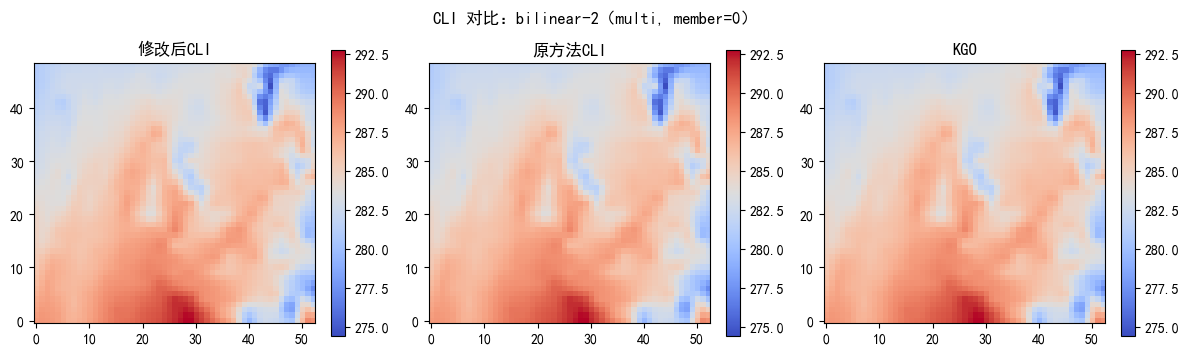

In [12]:
cli_multi_out = CLI_OUTPUT_DIR / "cli_bilinear2_multi_result.nc"
orig_cli_multi_out = CLI_OUTPUT_DIR / "original_cli_bilinear2_multi.nc"

# 修改后 CLI
cli_multi = cli_process(
    str(CLI_INPUT_DIR / "global_cutout_multi_realization.nc"),
    str(CLI_INPUT_DIR / "ukvx_landmask.nc"),
    land_sea_mask_path=None,
    output_path=str(cli_multi_out),
    regrid_mode="bilinear-2",
    regridded_title="test",
)
print("修改后 CLI bilinear-2 multi 写出:", cli_multi_out)

# 原方法 CLI
run_original_improver_regrid(
    DATA_DIR / "landmask/global_cutout_multi_realization.nc",
    DATA_DIR / "landmask/ukvx_landmask.nc",
    orig_cli_multi_out,
    regrid_mode="bilinear-2",
    regridded_title="test",
)
orig_cli_multi = iris.load_cube(str(orig_cli_multi_out))

summarize_triple("CLI bilinear-2 multi", cli_multi, orig_cli_multi, kgo_multi)
plot_triple(
    cli_multi,
    orig_cli_multi,
    kgo_multi,
    title="CLI 对比：bilinear-2（multi, member=0）",
    member_index=0,
    panel_titles=("修改后CLI", "原方法CLI", "KGO"),
)


## 7. 说明

- 官方样例 → meb：先运行 `python regrid/cli/preprocess_test_data.py`，写出 `test_data/cli_input/`。
- 第 2–4 节各场景各自读取本场景所需输入并绘图，再调用算法与对照 KGO。
- 第 5 节自包含读取同一 `src`/`tgt`，对照 `bilinear` 与 `bilinear-2`。
- CLI 与 pytest 均读 `cli_input/` 作算法输入。
- 修改后 CLI：`python regrid/cli/tran_regrid.py`；可在本 Notebook 第 6 节调用 `tran_regrid.process`。
- 原方法 CLI：`PYTHONPATH=improver-1.18.7 python -m improver.cli regrid ...`（见第 6 节 `run_original_improver_regrid`）。
- 全量测试：`pytest regrid/test -q`
- 原算法对照依赖 `improver-1.18.7` 与 `iris`。
